## PyTorch Generative AI / Reconstruction Example — Autoencoder on CIFAR-10

Following the **Generative AI Training Workflow** from the lecture:

1. **Data** — Load CIFAR-10 images
2. **Generative Model** — Define an Autoencoder (`nn.Module`) with encoder + decoder
3. **Train** — Reconstruct images using the shared training loop:
   - Forward pass: `x_hat = model(x)`
   - Objective: `loss = objective(x_hat, x)` (reconstruction loss / MSE)
   - Update: `loss.backward()` + `optimizer.step()`
   - Repeat over epochs/batches
4. **Reconstruction** — Visualize original vs. reconstructed images
5. **Evaluation** — Assess reconstruction quality

---

| Model | Output | Objective |
|-------|--------|-----------|
| **AE** | Reconstruction (x̂) | Reconstruction Loss (MSE) |

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


In [24]:
# 1. Data — load and normalize CIFAR-10 and Sample size configuration 
train_size = 5000    # number of training samples
test_size = 1000     # number of test samples
batch_size = 64      # batch size for data loaders
num_display = 8      # number of images to display in reconstruction

transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainset = torch.utils.data.Subset(trainset, range(train_size))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testset = torch.utils.data.Subset(testset, range(test_size))
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

## 2. Generative Model — Autoencoder

An Autoencoder compresses the input into a latent representation (`z = encoder(x)`) then reconstructs it (`x̂ = decoder(z)`).

This is the **Model** block from the lecture — a function with learnable parameters.

In [25]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # encoder: compress 3x32x32 image into a 64-dim latent vector
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),   # -> 16x16x16
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # -> 32x8x8
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # -> 64x4x4
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
        )
        # decoder: reconstruct from 64-dim latent back to 3x32x32
        self.decoder = nn.Sequential(
            nn.Linear(64, 64 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (64, 4, 4)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # -> 32x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # -> 16x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),   # -> 3x32x32
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

model = Autoencoder()
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1024, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=1024, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 4, 4))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (8): Sigmoid()
  )
)


## 3. Train the Model

The lecture's shared **generative AI training loop**:
```python
for x in dataloader:
    x_hat = model(x)              # reconstruction
    loss = objective(x_hat, x)    # reconstruction loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

In [26]:
# define objective and optimizer
objective = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
num_epochs = 50
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in trainloader:
        x, _ = data  # ignore labels — unsupervised learning

        x_hat = model(x)              # reconstruction
        loss = objective(x_hat, x)     # reconstruction loss (MSE)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

print('Finished Training')

Epoch [1/50], Loss: 0.0530
Epoch [2/50], Loss: 0.0288
Epoch [3/50], Loss: 0.0236
Epoch [4/50], Loss: 0.0211
Epoch [5/50], Loss: 0.0195
Epoch [6/50], Loss: 0.0184
Epoch [7/50], Loss: 0.0177
Epoch [8/50], Loss: 0.0169
Epoch [9/50], Loss: 0.0161
Epoch [10/50], Loss: 0.0148
Epoch [11/50], Loss: 0.0139
Epoch [12/50], Loss: 0.0134
Epoch [13/50], Loss: 0.0129
Epoch [14/50], Loss: 0.0124
Epoch [15/50], Loss: 0.0120
Epoch [16/50], Loss: 0.0118
Epoch [17/50], Loss: 0.0115
Epoch [18/50], Loss: 0.0115
Epoch [19/50], Loss: 0.0112
Epoch [20/50], Loss: 0.0111
Epoch [21/50], Loss: 0.0109
Epoch [22/50], Loss: 0.0107
Epoch [23/50], Loss: 0.0108
Epoch [24/50], Loss: 0.0104
Epoch [25/50], Loss: 0.0103
Epoch [26/50], Loss: 0.0102
Epoch [27/50], Loss: 0.0102
Epoch [28/50], Loss: 0.0100
Epoch [29/50], Loss: 0.0100
Epoch [30/50], Loss: 0.0098
Epoch [31/50], Loss: 0.0097
Epoch [32/50], Loss: 0.0097
Epoch [33/50], Loss: 0.0097
Epoch [34/50], Loss: 0.0095
Epoch [35/50], Loss: 0.0095
Epoch [36/50], Loss: 0.0095
E

## 4. Reconstruction

Visualize original images alongside their reconstructions to see what the autoencoder has learned.

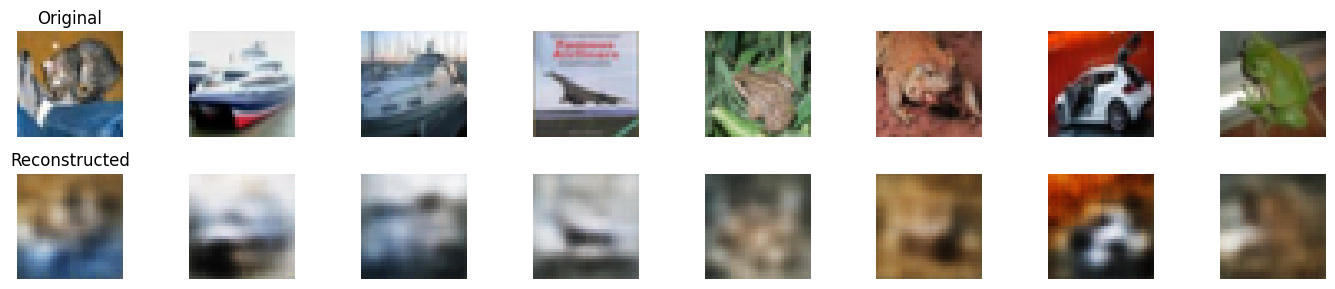

In [27]:
# get a batch of test images
dataiter = iter(testloader)
images, _ = next(dataiter)

# reconstruct
with torch.no_grad():
    reconstructed = model(images)

# display original vs reconstructed
n = min(num_display, len(images))
fig, axes = plt.subplots(2, n, figsize=(14, 3))
for i in range(n):
    # original
    axes[0, i].imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original')
    # reconstructed
    axes[1, i].imshow(np.transpose(reconstructed[i].numpy(), (1, 2, 0)))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed')
plt.tight_layout()
plt.show()

## 5. Evaluation

Measure average reconstruction loss (MSE) on the full test set.

In [22]:
# evaluate reconstruction quality on the test set
total_loss = 0.0
num_batches = 0

with torch.no_grad():
    for data in testloader:
        x, _ = data
        x_hat = model(x)
        loss = objective(x_hat, x)
        total_loss += loss.item()
        num_batches += 1

avg_test_loss = total_loss / num_batches
print(f'Average reconstruction loss (MSE) on test set: {avg_test_loss:.4f}')

Average reconstruction loss (MSE) on test set: 0.0649
